
# BioCatch Vishing Data Augmentation Pipeline

Este notebook implementa un pipeline híbrido de data augmentation para escalar un dataset sintético de comportamiento biométrico tipo BioCatch desde ~50k sesiones hasta ~1 millón de observaciones.

## Objetivos

- Simular un entorno bancario más cercano a producción
- Mantener fraude raro (~1%)
- Introducir drift temporal
- Introducir diversidad intra-clase
- Evitar synthetic collapse
- Preservar correlaciones plausibles
- Generar hard cases y sesiones ambiguas

## Estrategia General

1. Auditoría estructural del dataset
2. Limpieza y remoción de leakage
3. Simulación temporal y de clientes
4. Bootstrap perturbado
5. CTGAN / TVAE
6. Hard-case synthesis
7. Constraint engine
8. Drift injection
9. Adversarial validation
10. Exportación final


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance

import matplotlib.pyplot as plt
import seaborn as sns

from sdv.single_table import CTGANSynthesizer
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata

from tqdm import tqdm
from datetime import timedelta

import random


In [4]:
DATASET_PATH = "raw_data/dataset_sintetico_biocatch_vishing_overlap.csv"

df = pd.read_csv(DATASET_PATH)

print(df.shape)
df.head()

(50000, 61)


,session_id,customer_id,session_timestamp,device_type,os_type,app_version,avg_keyhold_ms,avg_interkey_latency_ms,typing_speed_cps,keystroke_variability,...,biocatch_genuine_score,biocatch_ato_indicator,biocatch_social_eng_indicator,biocatch_bot_indicator,errors_per_minute,interactions_per_s,hesitation_composite,is_vishing,days_to_claim,claim_category
0,SES-NO-000001,CUS-53613,2024-08-24 14:54:24,mobile,iOS,v13.0,97.7,178.4,3.777,0.240,...,896,0,0,0,8.717,2.4,1.1518,0,-1,none
1,SES-NO-000002,CUS-43723,2025-02-06 21:28:41,mobile,iOS,v12.3,72.8,78.5,3.016,0.086,...,670,1,0,0,8.717,2.4,1.0316,0,-1,none
2,SES-NO-000003,CUS-93608,2025-05-15 15:22:09,web,Windows,v12.3,86.7,152.3,4.776,0.141,...,838,0,0,0,0.000,2.4,1.1518,0,-1,none
3,SES-NO-000004,CUS-25829,2024-08-08 06:00:27,mobile,Android,v13.0,82.9,176.7,4.992,0.171,...,570,0,0,0,8.717,2.4,1.1518,0,-1,none
4,SES-NO-000005,CUS-46701,2024-09-04 11:09:02,mobile,Android,v12.1,69.9,204.0,6.337,0.133,...,1000,0,0,0,8.717,2.4,1.1518,0,-1,none


is_vishing
0    0.95
1    0.05
Name: proportion, dtype: float64


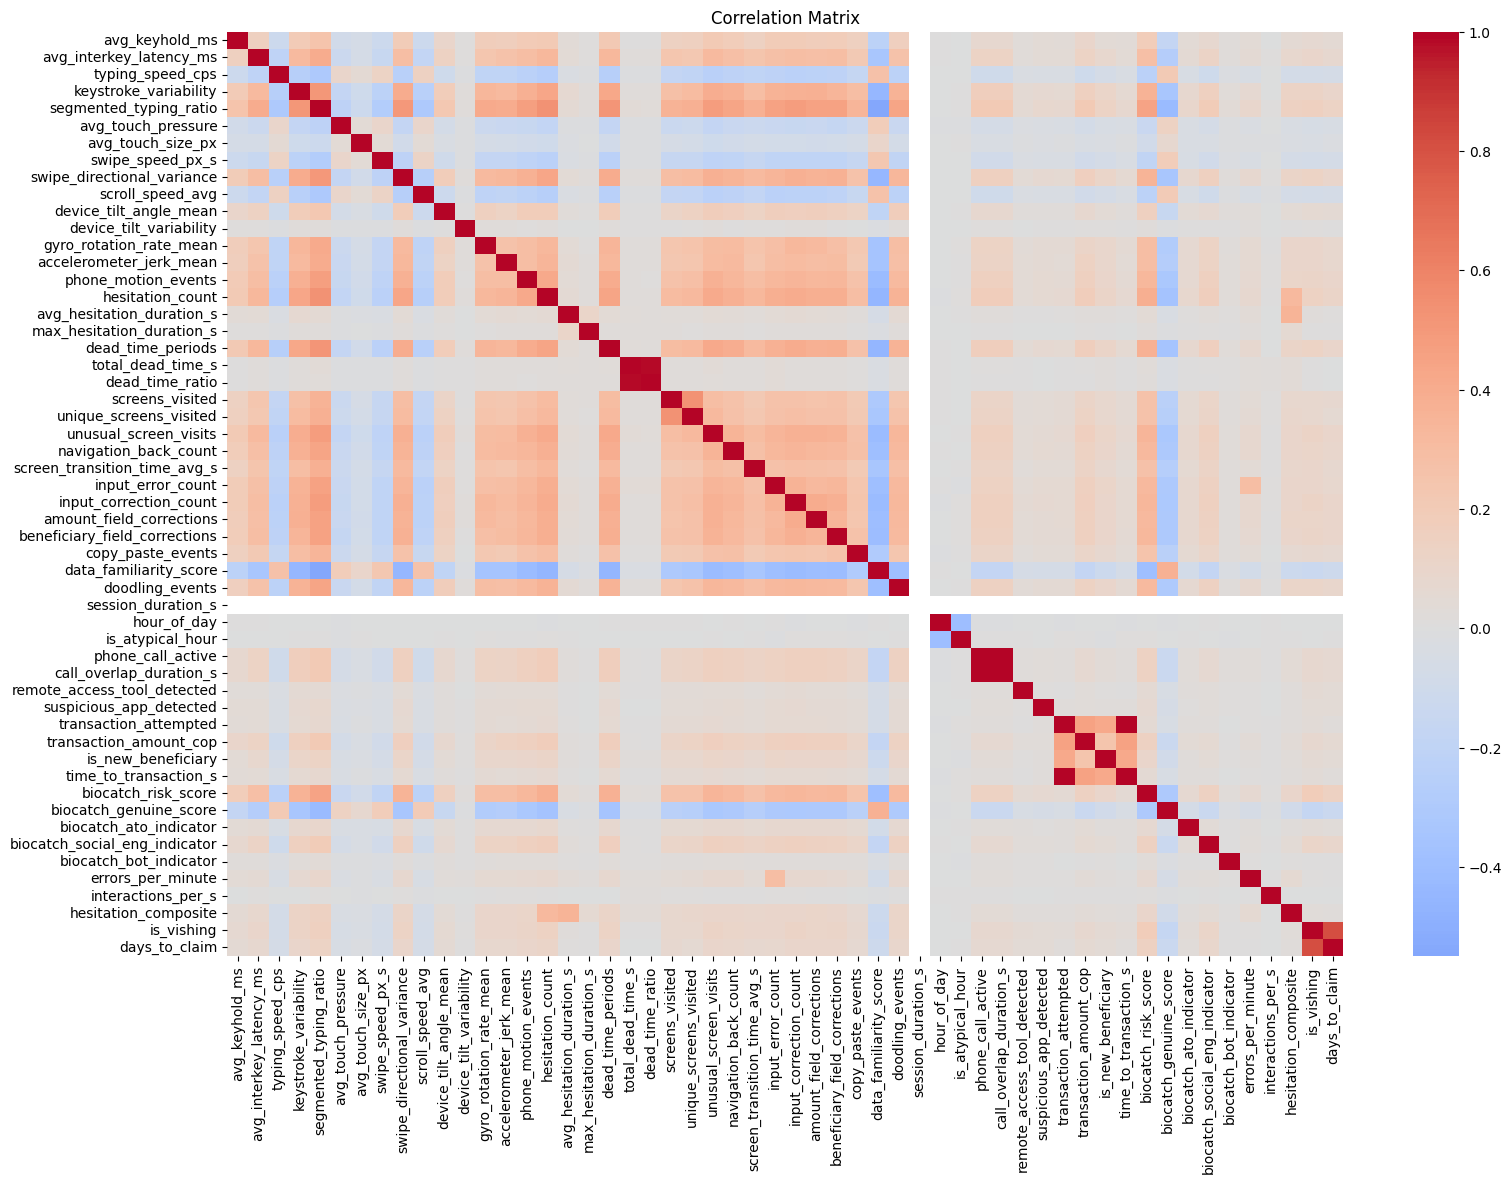

In [5]:

# =========================
# AUDITORÍA INICIAL
# =========================

print(df['is_vishing'].value_counts(normalize=True))

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

corr = df[numeric_cols].corr()

plt.figure(figsize=(18, 12))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


A pesar de que las variables pertenecientes a scores simulados de BioCatch no se usaran en la prediccion/clasificacion, incluirlas antes del data augmentation puede hacer que los modelos aprendan las relaciones derivadas de estas features en la generacion de data sintetica.

In [6]:

# =========================
# REMOCIÓN DE LEAKAGE
# =========================

leakage_cols = [
    'biocatch_risk_score',
    'biocatch_genuine_score',
    'biocatch_ato_indicator',
    'biocatch_social_eng_indicator',
    'biocatch_bot_indicator',
    'claim_category',
    'days_to_claim'
]

existing_leakage = [c for c in leakage_cols if c in df.columns]

df_model = df.drop(columns=existing_leakage)

print("Removed leakage columns:", existing_leakage)
print(df_model.shape)


Removed leakage columns: ['biocatch_risk_score', 'biocatch_genuine_score', 'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 'biocatch_bot_indicator', 'claim_category', 'days_to_claim']
(50000, 54)


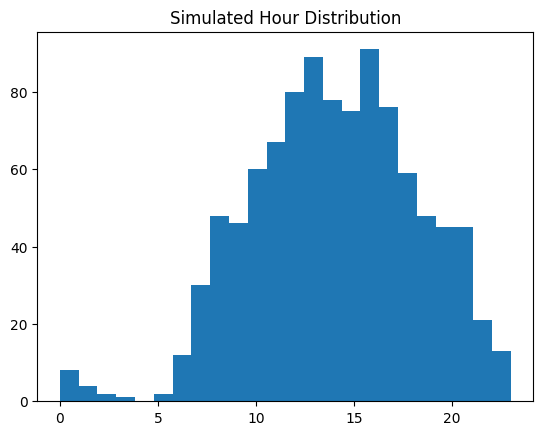

In [7]:

# =========================
# TEMPORAL SIMULATION
# =========================

df_model['session_timestamp'] = pd.to_datetime(df_model['session_timestamp'])

start_date = df_model['session_timestamp'].min()
end_date = start_date + pd.DateOffset(months=12)

date_range = pd.date_range(start_date, end_date, freq='H')

hour_weights = {
    0:0.2,1:0.1,2:0.05,3:0.05,4:0.05,
    5:0.1,6:0.4,7:0.8,8:1.2,9:1.5,
    10:1.7,11:1.8,12:2.0,13:2.2,14:2.0,
    15:2.3,16:2.5,17:2.4,18:1.8,19:1.5,
    20:1.2,21:1.0,22:0.6,23:0.4
}

def weighted_timestamp():
    while True:
        ts = np.random.choice(date_range)
        hour = pd.Timestamp(ts).hour
        if np.random.rand() < hour_weights[hour] / max(hour_weights.values()):
            return pd.Timestamp(ts)

sample_timestamps = [weighted_timestamp() for _ in range(1000)]

sample_hours = [x.hour for x in sample_timestamps]

plt.hist(sample_hours, bins=24)
plt.title("Simulated Hour Distribution")
plt.show()


In [8]:

# =========================
# CUSTOMER SESSION SIMULATION
# =========================

N_CUSTOMERS = 120000

customer_ids = [f"CUS-{i:06d}" for i in range(N_CUSTOMERS)]

# Distribución tipo Pareto/Zipf
session_counts = np.random.zipf(a=2.0, size=N_CUSTOMERS)

session_counts = np.clip(session_counts, 1, 200)

customer_session_map = pd.DataFrame({
    'customer_id': customer_ids,
    'session_count': session_counts
})

customer_session_map['session_count'].describe()


count    120000.000000
mean          4.108067
std          14.485108
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         200.000000
Name: session_count, dtype: float64

In [9]:

# =========================
# CLUSTERING PARA SUBTIPOS
# =========================

cluster_features = [
    'hesitation_count',
    'dead_time_periods',
    'segmented_typing_ratio',
    'keystroke_variability',
    'input_error_count'
]

cluster_features = [c for c in cluster_features if c in df_model.columns]

vishing_df = df_model[df_model['is_vishing'] == 1].copy()

kmeans = KMeans(n_clusters=4, random_state=42)

vishing_df['fraud_cluster'] = kmeans.fit_predict(
    vishing_df[cluster_features]
)

vishing_df['fraud_cluster'].value_counts()


fraud_cluster
1    1011
0     695
3     489
2     305
Name: count, dtype: int64

In [10]:

# =========================
# SDV METADATA
# =========================

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_model)

metadata


{
    "primary_key": "session_id",
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "session_id": {
            "sdtype": "id"
        },
        "customer_id": {
            "sdtype": "id"
        },
        "session_timestamp": {
            "sdtype": "datetime"
        },
        "device_type": {
            "sdtype": "categorical"
        },
        "os_type": {
            "sdtype": "categorical"
        },
        "app_version": {
            "sdtype": "categorical"
        },
        "avg_keyhold_ms": {
            "sdtype": "numerical"
        },
        "avg_interkey_latency_ms": {
            "sdtype": "numerical"
        },
        "typing_speed_cps": {
            "sdtype": "numerical"
        },
        "keystroke_variability": {
            "sdtype": "numerical"
        },
        "segmented_typing_ratio": {
            "sdtype": "numerical"
        },
        "avg_touch_pressure": {
            "sdtype": "numerical"
        },
        "avg_touch_s

In [11]:

# =========================
# CTGAN - LEGÍTIMOS
# =========================

legit_df = df_model[df_model['is_vishing'] == 0].copy()

ctgan_legit = CTGANSynthesizer(
    metadata=metadata,
    epochs=100,
    verbose=True
)

ctgan_legit.fit(legit_df)

print("CTGAN Legit Trained")


MemoryError: Unable to allocate 6.91 GiB for an array with shape (19515, 47500) and data type int64

In [ ]:

# =========================
# CTGAN - VISHING
# =========================

vishing_only = df_model[df_model['is_vishing'] == 1].copy()

ctgan_vishing = CTGANSynthesizer(
    metadata=metadata,
    epochs=150,
    verbose=True
)

ctgan_vishing.fit(vishing_only)

print("CTGAN Vishing Trained")


In [ ]:

# =========================
# TVAE - SUAVIZACIÓN DISTRIBUCIONAL
# =========================

tvae = TVAESynthesizer(
    metadata=metadata,
    epochs=100
)

tvae.fit(df_model)

print("TVAE trained")


In [ ]:

# =========================
# GENERACIÓN MASIVA
# =========================

TARGET_ROWS = 1_000_000
TARGET_VISHING = 10_000
TARGET_LEGIT = TARGET_ROWS - TARGET_VISHING

# -------------------------
# LEGÍTIMOS
# -------------------------

legit_ctgan = ctgan_legit.sample(num_rows=700_000)
legit_tvae = tvae.sample(num_rows=200_000)

bootstrap_legit = legit_df.sample(
    n=90_000,
    replace=True,
    random_state=42
).copy()

# -------------------------
# VISHING
# -------------------------

vishing_ctgan = ctgan_vishing.sample(num_rows=6_000)

vishing_tvae = tvae.sample(num_rows=2_000)

bootstrap_vishing = vishing_only.sample(
    n=2_000,
    replace=True,
    random_state=42
).copy()

print("Generation complete")


In [ ]:

# =========================
# HARD CASE GENERATION
# =========================

def generate_hard_legit(df_input, n=10000):

    hard = df_input.sample(n=n, replace=True).copy()

    if 'phone_call_active' in hard.columns:
        hard['phone_call_active'] = np.random.binomial(1, 0.35, size=n)

    if 'hesitation_count' in hard.columns:
        hard['hesitation_count'] *= np.random.uniform(1.2, 1.8, size=n)

    if 'copy_paste_events' in hard.columns:
        hard['copy_paste_events'] += np.random.poisson(1, size=n)

    hard['is_vishing'] = 0

    return hard

def generate_soft_vishing(df_input, n=2000):

    soft = df_input.sample(n=n, replace=True).copy()

    if 'hesitation_count' in soft.columns:
        soft['hesitation_count'] *= np.random.uniform(0.5, 0.8, size=n)

    if 'input_error_count' in soft.columns:
        soft['input_error_count'] *= np.random.uniform(0.5, 0.8, size=n)

    if 'phone_call_active' in soft.columns:
        soft['phone_call_active'] = np.random.binomial(1, 0.55, size=n)

    soft['is_vishing'] = 1

    return soft

hard_legit = generate_hard_legit(legit_df)
soft_vishing = generate_soft_vishing(vishing_only)

print(hard_legit.shape)
print(soft_vishing.shape)


In [ ]:

# =========================
# CONSTRAINT ENGINE
# =========================

def apply_constraints(df_aug):

    if 'phone_call_active' in df_aug.columns and 'call_overlap_duration_s' in df_aug.columns:
        mask = df_aug['phone_call_active'] == 0
        df_aug.loc[mask, 'call_overlap_duration_s'] = 0

    if 'transaction_attempted' in df_aug.columns and 'transaction_amount_cop' in df_aug.columns:
        mask = df_aug['transaction_attempted'] == 0
        df_aug.loc[mask, 'transaction_amount_cop'] = 0

    if 'dead_time_ratio' in df_aug.columns:
        df_aug['dead_time_ratio'] = np.clip(df_aug['dead_time_ratio'], 0, 1)

    if 'segmented_typing_ratio' in df_aug.columns:
        df_aug['segmented_typing_ratio'] = np.clip(
            df_aug['segmented_typing_ratio'],
            0,
            1
        )

    return df_aug

print("Constraint engine ready")


In [ ]:

# =========================
# COMBINACIÓN FINAL
# =========================

final_df = pd.concat([
    legit_ctgan,
    legit_tvae,
    bootstrap_legit,
    hard_legit,
    vishing_ctgan,
    vishing_tvae,
    bootstrap_vishing,
    soft_vishing,
    df_model
], ignore_index=True)

final_df = apply_constraints(final_df)

final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(final_df.shape)
print(final_df['is_vishing'].value_counts(normalize=True))


In [ ]:

# =========================
# DRIFT INJECTION
# =========================

if 'session_timestamp' in final_df.columns:

    final_df['session_timestamp'] = pd.to_datetime(
        final_df['session_timestamp'],
        errors='coerce'
    )

    final_df['month'] = final_df['session_timestamp'].dt.month

    if 'typing_speed_cps' in final_df.columns:

        drift_factor = {
            1:0.98, 2:0.99, 3:1.00, 4:1.01,
            5:1.02, 6:1.03, 7:1.04, 8:1.03,
            9:1.02, 10:1.01, 11:1.00, 12:0.99
        }

        final_df['typing_speed_cps'] = final_df.apply(
            lambda row: row['typing_speed_cps'] * drift_factor.get(row['month'], 1),
            axis=1
        )

print("Temporal drift injected")


In [ ]:

# =========================
# ADVERSARIAL VALIDATION
# =========================

orig = df_model.copy()
orig['synthetic'] = 0

synth = final_df.sample(n=min(len(final_df), len(orig)*3), random_state=42).copy()
synth['synthetic'] = 1

adv_df = pd.concat([orig, synth], ignore_index=True)

drop_cols = [
    'session_id',
    'customer_id',
    'session_timestamp'
]

drop_cols = [c for c in drop_cols if c in adv_df.columns]

X = adv_df.drop(columns=['synthetic'] + drop_cols)

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(0)

y = adv_df['synthetic']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

preds = clf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, preds)

print(f"Adversarial Validation AUC: {auc:.4f}")


In [ ]:

# =========================
# KS TEST & WASSERSTEIN
# =========================

comparison_results = []

numeric_cols = final_df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    if col == 'is_vishing':
        continue

    try:

        orig_values = df_model[col].dropna()
        synth_values = final_df[col].dropna()

        ks = ks_2samp(orig_values, synth_values).statistic

        wd = wasserstein_distance(orig_values, synth_values)

        comparison_results.append({
            'feature': col,
            'ks_stat': ks,
            'wasserstein': wd
        })

    except:
        pass

comparison_df = pd.DataFrame(comparison_results)

comparison_df.sort_values('ks_stat').head(20)


In [ ]:

# =========================
# EXPORTACIÓN FINAL
# =========================

OUTPUT_PATH = "biocatch_augmented_1M.csv"

final_df.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset exported to: {OUTPUT_PATH}")



# Mermaid Pipeline Diagram

```mermaid
flowchart TD

A[Original Dataset 50k] --> B[Leakage Removal]
B --> C[Structural Audit]
C --> D[Temporal Simulation]
D --> E[Customer Session Expansion]

E --> F1[Bootstrap + Noise]
E --> F2[CTGAN Legit]
E --> F3[CTGAN Vishing]
E --> F4[TVAE Generator]

F2 --> G[Legitimate Synthetic Sessions]
F3 --> H[Vishing Synthetic Sessions]
F4 --> I[Distribution Smoothing]

G --> J[Hard Legitimate Cases]
H --> K[Soft Vishing Cases]

J --> L[Constraint Engine]
K --> L
I --> L
F1 --> L

L --> M[Temporal Drift Injection]

M --> N[Adversarial Validation]
N --> O[KS / Wasserstein Validation]

O --> P[Final Dataset 1M Rows]
```
